
# 📈 Backtester de rebotes — RSI + Bollinger + Volumen

Este notebook implementa una lógica de **proceso**, no de señales aisladas:

**FUERA → CAÍDA DETECTADA → VIGILANCIA → REBOTE CONFIRMADO → COMPRA → POSIBLE TECHO → GIRO CONFIRMADO → VENTA**

Objetivo: evitar comprar mientras el precio todavía está cayendo con fuerza.

Características:

- Descarga histórico con `yfinance`
- Ticker configurable
- Rango gráfico configurable
- Ventana operativa configurable
- Capital inicial configurable
- Interés compuesto
- Detección de caída fuerte con RSI + Bollinger
- Confirmación de rebote con precio + RSI + volumen
- Detección de techo con RSI + Bollinger
- Confirmación de giro bajista con precio + RSI + volumen
- Stop por estructura: debajo del mínimo reciente del suelo
- Tabla de operaciones
- Curva de capital
- Si queda una operación abierta al final de la ventana, se anula


In [1]:

# ================================================================
# ⚙️ CELDA 1 — CONFIGURACIÓN PRINCIPAL
# ================================================================
# 👉 MODIFICA NORMALMENTE SOLO ESTA CELDA
# ================================================================

# ------------------------------------------------
# 1️⃣ VALOR
# ------------------------------------------------
# DEJA ACTIVA SOLO UNA LÍNEA

TICKER = "META"        # Meta
# TICKER = "AMZN"      # Amazon
# TICKER = "NVDA"      # NVIDIA
# TICKER = "MSFT"      # Microsoft
# TICKER = "AAPL"      # Apple
# TICKER = "GOOGL"     # Alphabet
# TICKER = "AVGO"      # Broadcom
# TICKER = "TSLA"      # Tesla
# TICKER = "COST"      # Costco
# TICKER = "NFLX"      # Netflix


# ------------------------------------------------
# 2️⃣ RANGO TOTAL DEL GRÁFICO / DESCARGA
# ------------------------------------------------
# Formato AAAA-MM-DD
# Conviene descargar margen ANTERIOR a la ventana operativa
# para que RSI/Bollinger/volumen estén bien calculados.

FECHA_GRAFICA_INICIO = "2025-08-20"
FECHA_GRAFICA_FIN    = "2026-08-20"


# ------------------------------------------------
# 3️⃣ VENTANA OPERATIVA
# ------------------------------------------------
# El algoritmo SOLO puede abrir operaciones dentro de esta ventana.

FECHA_OPERATIVA_INICIO = "2026-01-01"
FECHA_OPERATIVA_FIN    = "2026-06-01"


# ------------------------------------------------
# 4️⃣ CAPITAL
# ------------------------------------------------

CAPITAL_INICIAL = 10000.0
REINVERTIR_TODO = True


# ------------------------------------------------
# 5️⃣ RSI
# ------------------------------------------------

RSI_PERIODO = 14

# Zona de caída/suelo
RSI_SUELO = 35

# Zona de techo
RSI_TECHO = 68


# ------------------------------------------------
# 6️⃣ BOLLINGER
# ------------------------------------------------

BB_PERIODO = 20
BB_DESVIACIONES = 2.0


# ------------------------------------------------
# 7️⃣ VOLUMEN
# ------------------------------------------------

VOLUMEN_PERIODO = 20

# Confirmación de rebote:
# volumen actual > media * multiplicador
VOLUMEN_REBOTE_MULT = 1.10

# Confirmación de giro bajista:
VOLUMEN_SALIDA_MULT = 1.05


# ------------------------------------------------
# 8️⃣ DETECCIÓN DE CAÍDA FUERTE
# ------------------------------------------------

# Caída mínima acumulada en N sesiones para activar vigilancia.
CAIDA_SESIONES = 5
CAIDA_MIN_PCT = -6.0

# Cuántas sesiones esperamos un rebote tras detectar posible suelo.
DIAS_VIGILANCIA_SUELO = 7


# ------------------------------------------------
# 9️⃣ CONFIRMACIÓN DEL REBOTE
# ------------------------------------------------
# La compra exige estas condiciones.
#
# - RSI subiendo
# - cierre > cierre anterior
# - cierre vuelve dentro de Bollinger
# - cierre > máximo de la vela anterior
# - volumen relevante

EXIGIR_ROMPER_MAXIMO_ANTERIOR = True
EXIGIR_VOLUMEN_REBOTE = True

# Podemos exigir que el RSI haya recuperado un mínimo antes de comprar.
RSI_MIN_REBOTE = 28


# ------------------------------------------------
# 🔟 DETECCIÓN DE POSIBLE TECHO
# ------------------------------------------------

# Subida acumulada mínima reciente para considerar sobreextensión.
SUBIDA_SESIONES = 5
SUBIDA_MIN_PCT = 5.0

# Cuántos días esperamos confirmación bajista.
DIAS_VIGILANCIA_TECHO = 7


# ------------------------------------------------
# 1️⃣1️⃣ CONFIRMACIÓN DE SALIDA
# ------------------------------------------------
# - RSI bajando
# - cierre < cierre anterior
# - vuelve dentro desde la banda superior
# - cierre < mínimo de vela anterior
# - volumen relevante

EXIGIR_ROMPER_MINIMO_ANTERIOR = True
EXIGIR_VOLUMEN_SALIDA = True


# ------------------------------------------------
# 1️⃣2️⃣ STOP POR ESTRUCTURA
# ------------------------------------------------
# Se coloca debajo del mínimo observado durante la fase de suelo.

STOP_MARGEN_PCT = 1.5

# Si el precio avanza a favor, podemos subir el stop
# bajo el mínimo de las últimas N sesiones.
USAR_TRAILING_ESTRUCTURAL = True
TRAILING_MIN_SESIONES = 3
TRAILING_MARGEN_PCT = 1.0


# ------------------------------------------------
# 1️⃣3️⃣ COSTES
# ------------------------------------------------
# 0.10 = 0,10 %

COMISION_PCT = 0.0
SLIPPAGE_PCT = 0.0


# ------------------------------------------------
# 1️⃣4️⃣ FILTROS EXTRA
# ------------------------------------------------

# Evita volver a entrar inmediatamente después de una salida.
DIAS_ESPERA_TRAS_SALIDA = 2


print("=" * 72)
print("📊 CONFIGURACIÓN")
print("=" * 72)
print(f"Ticker:                 {TICKER}")
print(f"Gráfico:                {FECHA_GRAFICA_INICIO} → {FECHA_GRAFICA_FIN}")
print(f"Ventana operativa:      {FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}")
print(f"Capital inicial:        ${CAPITAL_INICIAL:,.2f}")
print(f"RSI suelo / techo:      {RSI_SUELO} / {RSI_TECHO}")
print(f"Caída mínima:           {CAIDA_MIN_PCT}% en {CAIDA_SESIONES} sesiones")
print(f"Volumen rebote:         {VOLUMEN_REBOTE_MULT:.2f}x media")
print(f"Stop bajo mínimo suelo: {STOP_MARGEN_PCT:.2f}%")
print("=" * 72)


📊 CONFIGURACIÓN
Ticker:                 META
Gráfico:                2025-08-20 → 2026-08-20
Ventana operativa:      2026-01-01 → 2026-06-01
Capital inicial:        $10,000.00
RSI suelo / techo:      35 / 68
Caída mínima:           -6.0% en 5 sesiones
Volumen rebote:         1.10x media
Stop bajo mínimo suelo: 1.50%


In [2]:

# ================================================================
# 📦 CELDA 2 — LIBRERÍAS
# ================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

print("✅ Librerías cargadas")


✅ Librerías cargadas


In [3]:

# ================================================================
# 📥 CELDA 3 — DESCARGAR HISTÓRICO
# ================================================================

print(f"📥 Descargando {TICKER}...")

df = yf.download(
    TICKER,
    start=FECHA_GRAFICA_INICIO,
    end=FECHA_GRAFICA_FIN,
    interval="1d",
    auto_adjust=False,
    progress=False
)

if df.empty:
    raise ValueError("No se han descargado datos. Revisa ticker y fechas.")

df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

columnas = ["Date", "Open", "High", "Low", "Close", "Volume"]
df = df[[x for x in columnas if x in df.columns]].copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print(f"✅ {len(df)} sesiones descargadas")
print(f"Desde: {df['Date'].min().date()}")
print(f"Hasta: {df['Date'].max().date()}")

display(df.tail())


📥 Descargando META...
✅ 251 sesiones descargadas
Desde: 2025-08-20
Hasta: 2026-08-19


,Date,Open,High,Low,Close,Volume
246,2026-08-13,580.710022,595.849976,579.390015,594.969971,11164200
247,2026-08-14,596.979980,601.859985,589.289978,589.849976,8758000
248,2026-08-17,589.750000,590.239990,564.750000,568.969971,17225600
249,2026-08-18,557.479980,560.659973,543.210022,543.669983,27094900
250,2026-08-19,541.340027,554.059998,537.280029,546.030029,16348636


In [4]:

# ================================================================
# 🧮 CELDA 4 — INDICADORES
# ================================================================

data = df.copy()

# ------------------------------------------------
# RSI (Wilder)
# ------------------------------------------------

delta = data["Close"].diff()

ganancia = delta.clip(lower=0)
perdida = -delta.clip(upper=0)

avg_gain = ganancia.ewm(
    alpha=1 / RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

avg_loss = perdida.ewm(
    alpha=1 / RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

rs = avg_gain / avg_loss.replace(0, np.nan)

data["RSI"] = 100 - (100 / (1 + rs))


# ------------------------------------------------
# BOLLINGER
# ------------------------------------------------

data["BB_Media"] = data["Close"].rolling(BB_PERIODO).mean()

bb_std = data["Close"].rolling(BB_PERIODO).std(ddof=0)

data["BB_Sup"] = data["BB_Media"] + BB_DESVIACIONES * bb_std
data["BB_Inf"] = data["BB_Media"] - BB_DESVIACIONES * bb_std


# ------------------------------------------------
# VOLUMEN
# ------------------------------------------------

data["Vol_Media"] = data["Volume"].rolling(VOLUMEN_PERIODO).mean()


# ------------------------------------------------
# VARIACIONES ACUMULADAS
# ------------------------------------------------

data["Caida_pct"] = (
    data["Close"] / data["Close"].shift(CAIDA_SESIONES) - 1
) * 100

data["Subida_pct"] = (
    data["Close"] / data["Close"].shift(SUBIDA_SESIONES) - 1
) * 100


print("✅ Indicadores calculados")

display(
    data[
        [
            "Date", "Close", "RSI",
            "BB_Inf", "BB_Media", "BB_Sup",
            "Volume", "Vol_Media",
            "Caida_pct", "Subida_pct"
        ]
    ].tail(10)
)


✅ Indicadores calculados


,Date,Close,RSI,BB_Inf,BB_Media,BB_Sup,Volume,Vol_Media,Caida_pct,Subida_pct
241,2026-08-06,589.900024,47.004349,537.894359,616.121997,694.349636,11811500,18719170.0,9.437321,9.437321
242,2026-08-07,592.099976,47.668632,537.354228,612.266495,687.178761,11250300,17251240.0,6.356982,6.356982
243,2026-08-10,594.919983,48.558747,536.799045,609.175995,681.552945,14967300,17007570.0,0.792897,0.792897
244,2026-08-11,599.119995,49.924873,537.652427,606.079996,674.507564,13146900,16827505.0,1.901553,1.901553
245,2026-08-12,578.849976,43.869628,541.009220,600.956995,660.904769,16186900,16686680.0,-1.684876,-1.684876
246,2026-08-13,594.969971,49.151505,545.095810,597.478494,649.861178,11164200,16454090.0,0.859459,0.859459
247,2026-08-14,589.849976,47.618802,547.204891,594.670493,642.136094,8758000,15778595.0,-0.380003,-0.380003
248,2026-08-17,568.969971,41.882876,548.375185,590.826492,633.277799,17225600,16128615.0,-4.361933,-4.361933
249,2026-08-18,543.669983,36.193891,546.005799,585.819492,625.633185,27094900,17026335.0,-9.255243,-9.255243
250,2026-08-19,546.030029,37.052824,543.110704,581.762494,620.414284,16348636,17292786.8,-5.669854,-5.669854


In [5]:

# ================================================================
# 🚦 CELDA 5 — SEÑALES DEL PROCESO
# ================================================================

sig = data.copy()

# ------------------------------------------------
# A) DETECTAR CAÍDA FUERTE / POSIBLE SUELO
# ------------------------------------------------
#
# Se activa vigilancia cuando:
# - RSI está en zona baja
# - precio toca/perfora banda inferior
# - y existe caída acumulada relevante

sig["Caida_Fuerte"] = (
    (sig["RSI"] <= RSI_SUELO) &
    (sig["Close"] <= sig["BB_Inf"]) &
    (sig["Caida_pct"] <= CAIDA_MIN_PCT)
)


# ------------------------------------------------
# B) CONFIRMAR REBOTE
# ------------------------------------------------

sig["RSI_Subiendo"] = sig["RSI"] > sig["RSI"].shift(1)
sig["Precio_Subiendo"] = sig["Close"] > sig["Close"].shift(1)
sig["Dentro_Bollinger_Inf"] = sig["Close"] > sig["BB_Inf"]

sig["Rompe_Max_Anterior"] = (
    sig["Close"] > sig["High"].shift(1)
)

sig["Volumen_Rebote_OK"] = (
    sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_REBOTE_MULT
)

cond_rebote = (
    sig["RSI_Subiendo"] &
    sig["Precio_Subiendo"] &
    sig["Dentro_Bollinger_Inf"] &
    (sig["RSI"] >= RSI_MIN_REBOTE)
)

if EXIGIR_ROMPER_MAXIMO_ANTERIOR:
    cond_rebote &= sig["Rompe_Max_Anterior"]

if EXIGIR_VOLUMEN_REBOTE:
    cond_rebote &= sig["Volumen_Rebote_OK"]

sig["Rebote_Confirmado"] = cond_rebote


# ------------------------------------------------
# C) DETECTAR POSIBLE TECHO
# ------------------------------------------------

sig["Posible_Techo"] = (
    (sig["RSI"] >= RSI_TECHO) &
    (sig["Close"] >= sig["BB_Sup"]) &
    (sig["Subida_pct"] >= SUBIDA_MIN_PCT)
)


# ------------------------------------------------
# D) CONFIRMAR GIRO BAJISTA
# ------------------------------------------------

sig["RSI_Bajando"] = sig["RSI"] < sig["RSI"].shift(1)
sig["Precio_Bajando"] = sig["Close"] < sig["Close"].shift(1)

sig["Vuelve_Dentro_BB_Sup"] = (
    sig["Close"] < sig["BB_Sup"]
)

sig["Rompe_Min_Anterior"] = (
    sig["Close"] < sig["Low"].shift(1)
)

sig["Volumen_Salida_OK"] = (
    sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_SALIDA_MULT
)

cond_salida = (
    sig["RSI_Bajando"] &
    sig["Precio_Bajando"] &
    sig["Vuelve_Dentro_BB_Sup"]
)

if EXIGIR_ROMPER_MINIMO_ANTERIOR:
    cond_salida &= sig["Rompe_Min_Anterior"]

if EXIGIR_VOLUMEN_SALIDA:
    cond_salida &= sig["Volumen_Salida_OK"]

sig["Giro_Bajista_Confirmado"] = cond_salida


print("✅ Señales del proceso preparadas")


✅ Señales del proceso preparadas


In [6]:

# ================================================================
# 🧪 CELDA 6 — MOTOR DE BACKTEST CON MÁQUINA DE ESTADOS
# ================================================================
#
# ESTADOS:
#
# FUERA
#   ↓
# VIGILANDO_SUELO
#   ↓
# EN_POSICION
#   ↓
# VIGILANDO_TECHO
#   ↓
# FUERA
#
# La señal se detecta al cierre.
# La compra/venta por señal se ejecuta en la apertura siguiente.
# El stop sí puede ejecutarse intradía usando Low.
# ================================================================

fecha_ini = pd.Timestamp(FECHA_OPERATIVA_INICIO)
fecha_fin = pd.Timestamp(FECHA_OPERATIVA_FIN)

if fecha_ini >= fecha_fin:
    raise ValueError("La fecha inicial debe ser anterior a la fecha final.")

capital = float(CAPITAL_INICIAL)

estado = "FUERA"

dias_vigilando_suelo = 0
dias_vigilando_techo = 0

minimo_suelo = None
entrada = {}

operaciones = []
eventos = []

ultima_salida_indice = -999


for i in range(1, len(sig) - 1):

    ayer = sig.iloc[i - 1]
    hoy = sig.iloc[i]
    manana = sig.iloc[i + 1]

    fecha_hoy = hoy["Date"]
    fecha_manana = manana["Date"]


    # ============================================================
    # 1) ESTADO FUERA
    # ============================================================

    if estado == "FUERA":

        # No buscamos entradas demasiado pronto tras una salida
        if i - ultima_salida_indice <= DIAS_ESPERA_TRAS_SALIDA:
            continue

        if bool(hoy["Caida_Fuerte"]):

            estado = "VIGILANDO_SUELO"
            dias_vigilando_suelo = 0
            minimo_suelo = hoy["Low"]

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "CAÍDA FUERTE / VIGILAR SUELO",
                "Precio": hoy["Close"]
            })

        continue


    # ============================================================
    # 2) VIGILANDO SUELO
    # ============================================================

    if estado == "VIGILANDO_SUELO":

        dias_vigilando_suelo += 1

        # Actualizamos el mínimo de la caída
        minimo_suelo = min(minimo_suelo, hoy["Low"])

        # Si pasan demasiados días sin rebote, abandonamos vigilancia
        if dias_vigilando_suelo > DIAS_VIGILANCIA_SUELO:

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "FIN VIGILANCIA SUELO SIN ENTRADA",
                "Precio": hoy["Close"]
            })

            estado = "FUERA"
            minimo_suelo = None
            continue

        # Confirmación de rebote.
        # La COMPRA se ejecuta mañana si mañana está dentro de ventana.
        if (
            bool(hoy["Rebote_Confirmado"]) and
            fecha_manana >= fecha_ini and
            fecha_manana <= fecha_fin
        ):

            precio_entrada = manana["Open"] * (1 + SLIPPAGE_PCT / 100)

            capital_para_operar = (
                capital if REINVERTIR_TODO else CAPITAL_INICIAL
            )

            factor_comision = 1 + COMISION_PCT / 100

            acciones = capital_para_operar / (
                precio_entrada * factor_comision
            )

            importe_compra = acciones * precio_entrada
            coste_compra = importe_compra * (COMISION_PCT / 100)

            capital_invertido_neto = importe_compra + coste_compra

            stop_inicial = minimo_suelo * (
                1 - STOP_MARGEN_PCT / 100
            )

            entrada = {
                "fecha": fecha_manana,
                "precio": precio_entrada,
                "acciones": acciones,
                "capital_antes": capital,
                "capital_invertido_neto": capital_invertido_neto,
                "stop_inicial": stop_inicial,
                "stop_actual": stop_inicial,
                "minimo_suelo": minimo_suelo
            }

            eventos.append({
                "Fecha": fecha_manana,
                "Evento": "COMPRA",
                "Precio": precio_entrada
            })

            estado = "EN_POSICION"
            dias_vigilando_suelo = 0
            minimo_suelo = None

        continue


    # ============================================================
    # 3) EN POSICIÓN
    # ============================================================

    if estado == "EN_POSICION":

        # --------------------------------------------------------
        # TRAILING ESTRUCTURAL
        # --------------------------------------------------------

        if USAR_TRAILING_ESTRUCTURAL and i >= TRAILING_MIN_SESIONES:

            ventana_min = sig.iloc[
                i - TRAILING_MIN_SESIONES : i
            ]["Low"].min()

            nuevo_stop = ventana_min * (
                1 - TRAILING_MARGEN_PCT / 100
            )

            # El stop nunca baja
            entrada["stop_actual"] = max(
                entrada["stop_actual"],
                nuevo_stop
            )

        # --------------------------------------------------------
        # STOP INTRADÍA
        # --------------------------------------------------------

        if hoy["Low"] <= entrada["stop_actual"]:

            precio_salida = entrada["stop_actual"] * (
                1 - SLIPPAGE_PCT / 100
            )

            importe_salida = entrada["acciones"] * precio_salida
            coste_salida = importe_salida * (COMISION_PCT / 100)

            capital_final_op = importe_salida - coste_salida

            ganancia_pct = (
                capital_final_op /
                entrada["capital_invertido_neto"] - 1
            ) * 100

            capital = capital_final_op

            operaciones.append({
                "Entrada": entrada["fecha"],
                "Precio entrada": entrada["precio"],
                "Salida": fecha_hoy,
                "Precio salida": precio_salida,
                "Motivo salida": "STOP",
                "Ganancia %": ganancia_pct,
                "Capital antes": entrada["capital_antes"],
                "Capital después": capital,
                "Stop inicial": entrada["stop_inicial"],
                "Stop final": entrada["stop_actual"],
                "Mínimo suelo": entrada["minimo_suelo"]
            })

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "SALIDA STOP",
                "Precio": precio_salida
            })

            estado = "FUERA"
            entrada = {}
            ultima_salida_indice = i
            continue

        # --------------------------------------------------------
        # POSIBLE TECHO
        # --------------------------------------------------------

        if bool(hoy["Posible_Techo"]):

            estado = "VIGILANDO_TECHO"
            dias_vigilando_techo = 0

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "POSIBLE TECHO",
                "Precio": hoy["Close"]
            })

        continue


    # ============================================================
    # 4) VIGILANDO TECHO
    # ============================================================

    if estado == "VIGILANDO_TECHO":

        dias_vigilando_techo += 1

        # Seguimos protegiendo la posición con trailing
        if USAR_TRAILING_ESTRUCTURAL and i >= TRAILING_MIN_SESIONES:

            ventana_min = sig.iloc[
                i - TRAILING_MIN_SESIONES : i
            ]["Low"].min()

            nuevo_stop = ventana_min * (
                1 - TRAILING_MARGEN_PCT / 100
            )

            entrada["stop_actual"] = max(
                entrada["stop_actual"],
                nuevo_stop
            )

        # STOP
        if hoy["Low"] <= entrada["stop_actual"]:

            precio_salida = entrada["stop_actual"] * (
                1 - SLIPPAGE_PCT / 100
            )

            importe_salida = entrada["acciones"] * precio_salida
            coste_salida = importe_salida * (COMISION_PCT / 100)

            capital_final_op = importe_salida - coste_salida

            ganancia_pct = (
                capital_final_op /
                entrada["capital_invertido_neto"] - 1
            ) * 100

            capital = capital_final_op

            operaciones.append({
                "Entrada": entrada["fecha"],
                "Precio entrada": entrada["precio"],
                "Salida": fecha_hoy,
                "Precio salida": precio_salida,
                "Motivo salida": "STOP",
                "Ganancia %": ganancia_pct,
                "Capital antes": entrada["capital_antes"],
                "Capital después": capital,
                "Stop inicial": entrada["stop_inicial"],
                "Stop final": entrada["stop_actual"],
                "Mínimo suelo": entrada["minimo_suelo"]
            })

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "SALIDA STOP",
                "Precio": precio_salida
            })

            estado = "FUERA"
            entrada = {}
            ultima_salida_indice = i
            continue

        # Confirmación de giro bajista:
        # señal hoy -> venta mañana.
        if (
            bool(hoy["Giro_Bajista_Confirmado"]) and
            fecha_manana <= fecha_fin
        ):

            precio_salida = manana["Open"] * (
                1 - SLIPPAGE_PCT / 100
            )

            importe_salida = entrada["acciones"] * precio_salida
            coste_salida = importe_salida * (COMISION_PCT / 100)

            capital_final_op = importe_salida - coste_salida

            ganancia_pct = (
                capital_final_op /
                entrada["capital_invertido_neto"] - 1
            ) * 100

            capital = capital_final_op

            operaciones.append({
                "Entrada": entrada["fecha"],
                "Precio entrada": entrada["precio"],
                "Salida": fecha_manana,
                "Precio salida": precio_salida,
                "Motivo salida": "GIRO BAJISTA",
                "Ganancia %": ganancia_pct,
                "Capital antes": entrada["capital_antes"],
                "Capital después": capital,
                "Stop inicial": entrada["stop_inicial"],
                "Stop final": entrada["stop_actual"],
                "Mínimo suelo": entrada["minimo_suelo"]
            })

            eventos.append({
                "Fecha": fecha_manana,
                "Evento": "VENTA GIRO BAJISTA",
                "Precio": precio_salida
            })

            estado = "FUERA"
            entrada = {}
            ultima_salida_indice = i
            continue

        # Si no confirma techo en X días,
        # volvemos a estado EN_POSICION.
        if dias_vigilando_techo > DIAS_VIGILANCIA_TECHO:

            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "TECHO NO CONFIRMADO / SEGUIR",
                "Precio": hoy["Close"]
            })

            estado = "EN_POSICION"
            dias_vigilando_techo = 0

        continue


# ================================================================
# REGLA FINAL DE VENTANA
# ================================================================

operacion_anulada = None

if estado in ["EN_POSICION", "VIGILANDO_TECHO"] and entrada:

    operacion_anulada = {
        "Entrada anulada": entrada["fecha"],
        "Precio entrada": entrada["precio"],
        "Motivo": "Seguía abierta al finalizar la ventana operativa"
    }

    # Restauramos capital previo.
    capital = entrada["capital_antes"]

    eventos.append({
        "Fecha": fecha_fin,
        "Evento": "OPERACIÓN ANULADA FIN VENTANA",
        "Precio": np.nan
    })

    estado = "FUERA"
    entrada = {}


ops = pd.DataFrame(operaciones)
eventos_df = pd.DataFrame(eventos)

print("=" * 80)
print("✅ BACKTEST TERMINADO")
print("=" * 80)
print(f"Capital inicial: ${CAPITAL_INICIAL:,.2f}")
print(f"Capital final:   ${capital:,.2f}")
print(f"Rentabilidad:    {(capital/CAPITAL_INICIAL - 1)*100:+.2f}%")
print(f"Operaciones:     {len(ops)}")

if operacion_anulada:
    print()
    print("⚠️ OPERACIÓN FINAL ANULADA")
    print(f"Entrada: {operacion_anulada['Entrada anulada'].date()}")
    print(f"Precio:  ${operacion_anulada['Precio entrada']:.2f}")


✅ BACKTEST TERMINADO
Capital inicial: $10,000.00
Capital final:   $11,395.25
Rentabilidad:    +13.95%
Operaciones:     1


In [7]:

# ================================================================
# 📋 CELDA 7 — TABLA DE OPERACIONES
# ================================================================

if ops.empty:

    print("No se completó ninguna operación dentro de la ventana.")

else:

    tabla = ops.copy()

    for col in [
        "Precio entrada",
        "Precio salida",
        "Stop inicial",
        "Stop final",
        "Mínimo suelo"
    ]:
        tabla[col] = tabla[col].map(lambda x: f"${x:,.2f}")

    tabla["Ganancia %"] = tabla["Ganancia %"].map(
        lambda x: f"{x:+.2f}%"
    )

    tabla["Capital antes"] = tabla["Capital antes"].map(
        lambda x: f"${x:,.2f}"
    )

    tabla["Capital después"] = tabla["Capital después"].map(
        lambda x: f"${x:,.2f}"
    )

    display(tabla)

if operacion_anulada:

    print()
    print("Entrada anulada por quedar abierta al final de la ventana:")
    display(pd.DataFrame([operacion_anulada]))


,Entrada,Precio entrada,Salida,Precio salida,Motivo salida,Ganancia %,Capital antes,Capital después,Stop inicial,Stop final,Mínimo suelo
0,2026-04-01,$580.13,2026-04-23,$661.07,STOP,+13.95%,"$10,000.00","$11,395.25",$512.46,$661.07,$520.26


In [8]:

# ================================================================
# 🧭 CELDA 8 — EVENTOS DEL ALGORITMO
# ================================================================
# Muy útil para entender POR QUÉ entró o no entró.

if eventos_df.empty:
    print("No se detectaron eventos.")

else:
    display(eventos_df)


,Fecha,Evento,Precio
0,2025-10-30,CAÍDA FUERTE / VIGILAR SUELO,666.469971
1,2025-11-11,FIN VIGILANCIA SUELO SIN ENTRADA,627.080017
2,2026-03-26,CAÍDA FUERTE / VIGILAR SUELO,547.539978
3,2026-04-01,COMPRA,580.130005
4,2026-04-23,SALIDA STOP,661.072500
5,2026-07-30,CAÍDA FUERTE / VIGILAR SUELO,539.030029
6,2026-08-11,FIN VIGILANCIA SUELO SIN ENTRADA,599.119995


In [9]:

# ================================================================
# 📊 CELDA 9 — RESUMEN ESTADÍSTICO
# ================================================================

if ops.empty:

    print("Sin operaciones cerradas para calcular estadísticas.")

else:

    positivas = (ops["Ganancia %"] > 0).sum()
    negativas = (ops["Ganancia %"] <= 0).sum()

    acierto = positivas / len(ops) * 100

    mejor = ops["Ganancia %"].max()
    peor = ops["Ganancia %"].min()
    media = ops["Ganancia %"].mean()

    equity = pd.Series(
        [CAPITAL_INICIAL] + ops["Capital después"].tolist(),
        dtype=float
    )

    max_acum = equity.cummax()
    drawdown = (equity / max_acum - 1) * 100
    max_drawdown = drawdown.min()

    print("=" * 65)
    print(f"📊 RESULTADOS — {TICKER}")
    print("=" * 65)
    print(f"Capital inicial:       ${CAPITAL_INICIAL:,.2f}")
    print(f"Capital final:         ${capital:,.2f}")
    print(f"Rentabilidad total:    {(capital/CAPITAL_INICIAL - 1)*100:+.2f}%")
    print(f"Operaciones cerradas:  {len(ops)}")
    print(f"Ganadoras:             {positivas}")
    print(f"Perdedoras:            {negativas}")
    print(f"Acierto:               {acierto:.1f}%")
    print(f"Ganancia media/op.:    {media:+.2f}%")
    print(f"Mejor operación:       {mejor:+.2f}%")
    print(f"Peor operación:        {peor:+.2f}%")
    print(f"Drawdown aprox.:       {max_drawdown:.2f}%")
    print("=" * 65)


📊 RESULTADOS — META
Capital inicial:       $10,000.00
Capital final:         $11,395.25
Rentabilidad total:    +13.95%
Operaciones cerradas:  1
Ganadoras:             1
Perdedoras:            0
Acierto:               100.0%
Ganancia media/op.:    +13.95%
Mejor operación:       +13.95%
Peor operación:        +13.95%
Drawdown aprox.:       0.00%



## 🧠 Qué hace exactamente esta estrategia

### Entrada

Primero busca una caída fuerte:

- RSI bajo
- cierre en/bajo Bollinger inferior
- caída acumulada relevante

Eso **NO compra**.

Activa un estado de vigilancia durante varios días.

Solo compra cuando aparece un rebote confirmado:

- RSI subiendo
- precio subiendo
- precio vuelve dentro de Bollinger
- opcionalmente rompe el máximo de la vela anterior
- volumen superior a su media

La orden se ejecuta en la apertura de la sesión siguiente.

### Salida

Primero busca una posible zona de techo:

- RSI elevado
- cierre en/sobre Bollinger superior
- subida acumulada reciente

Eso **NO vende todavía**.

Después espera un giro bajista:

- RSI bajando
- precio bajando
- vuelve dentro desde Bollinger superior
- opcionalmente rompe el mínimo de la vela anterior
- volumen relevante

La venta se ejecuta en la apertura siguiente.

### Stop

El stop inicial se coloca debajo del mínimo observado durante la fase de suelo.  
También puede ir subiendo bajo los mínimos recientes mediante `USAR_TRAILING_ESTRUCTURAL`.

### Importante

Esta estrategia busca **confirmación**, no acertar exactamente el mínimo o máximo. Por diseño, normalmente comprará por encima del mínimo real y venderá por debajo del máximo real. La idea es reducir entradas prematuras durante caídas violentas.


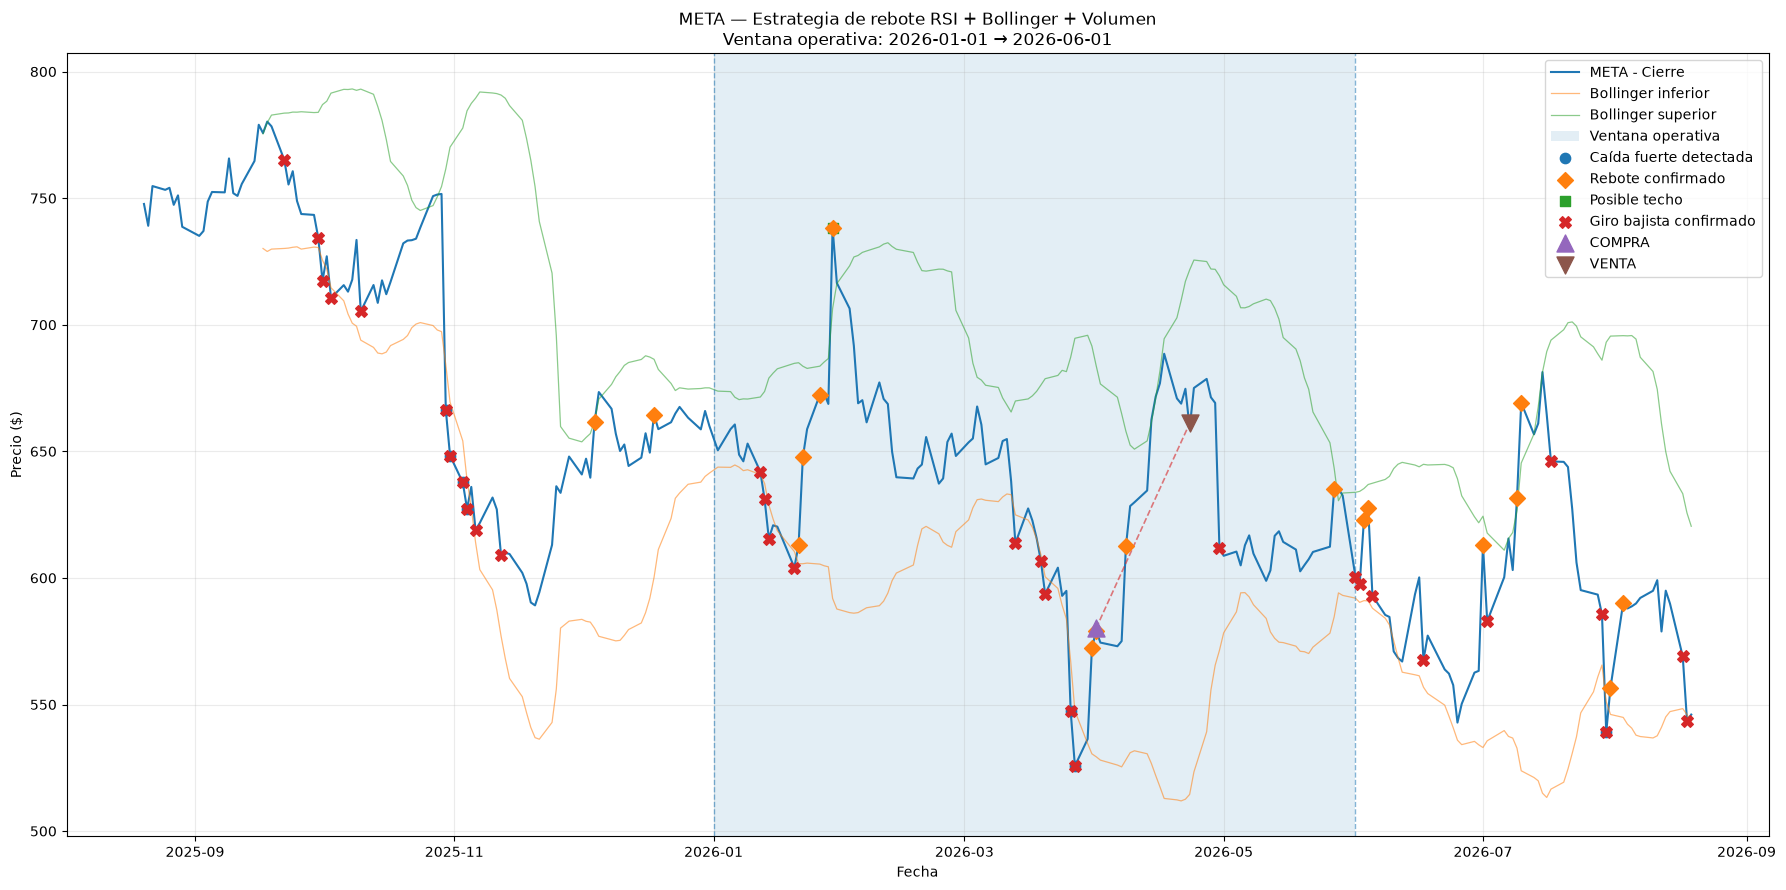


🔎 RESUMEN DE SEÑALES
Caídas fuertes detectadas:       7
Rebotes confirmados:             17
Posibles techos detectados:      1
Giros bajistas confirmados:      31
Operaciones completadas:         1


In [10]:

# ================================================================
# 📈 CELDA FINAL — GRÁFICA COMPLETA DEL BACKTEST
# ================================================================
# ESTA GRÁFICA SALE SIEMPRE, HAYA O NO HAYA OPERACIONES.
#
# Muestra:
# - Todo el rango histórico descargado
# - Ventana operativa sombreada
# - Bandas de Bollinger
# - Caídas fuertes detectadas
# - Rebotes confirmados
# - Posibles techos
# - Giros bajistas confirmados
# - Compras reales
# - Ventas reales
# ================================================================

fig, ax = plt.subplots(figsize=(18, 9))

# ------------------------------------------------
# PRECIO
# ------------------------------------------------
ax.plot(
    sig["Date"],
    sig["Close"],
    linewidth=1.5,
    label=f"{TICKER} - Cierre"
)

# ------------------------------------------------
# BOLLINGER
# ------------------------------------------------
ax.plot(
    sig["Date"],
    sig["BB_Inf"],
    linewidth=0.9,
    alpha=0.55,
    label="Bollinger inferior"
)

ax.plot(
    sig["Date"],
    sig["BB_Sup"],
    linewidth=0.9,
    alpha=0.55,
    label="Bollinger superior"
)

# ------------------------------------------------
# VENTANA OPERATIVA SOMBREADA
# ------------------------------------------------
ax.axvspan(
    pd.Timestamp(FECHA_OPERATIVA_INICIO),
    pd.Timestamp(FECHA_OPERATIVA_FIN),
    alpha=0.12,
    label="Ventana operativa"
)

# Límites exactos de la ventana
ax.axvline(
    pd.Timestamp(FECHA_OPERATIVA_INICIO),
    linestyle="--",
    linewidth=1,
    alpha=0.55
)

ax.axvline(
    pd.Timestamp(FECHA_OPERATIVA_FIN),
    linestyle="--",
    linewidth=1,
    alpha=0.55
)

# ------------------------------------------------
# SEÑALES DIAGNÓSTICAS
# ------------------------------------------------

caidas = sig[sig["Caida_Fuerte"]]

if not caidas.empty:
    ax.scatter(
        caidas["Date"],
        caidas["Close"],
        marker="o",
        s=55,
        label="Caída fuerte detectada",
        zorder=5
    )

rebotes = sig[sig["Rebote_Confirmado"]]

if not rebotes.empty:
    ax.scatter(
        rebotes["Date"],
        rebotes["Close"],
        marker="D",
        s=65,
        label="Rebote confirmado",
        zorder=6
    )

techos = sig[sig["Posible_Techo"]]

if not techos.empty:
    ax.scatter(
        techos["Date"],
        techos["Close"],
        marker="s",
        s=55,
        label="Posible techo",
        zorder=5
    )

giros = sig[sig["Giro_Bajista_Confirmado"]]

if not giros.empty:
    ax.scatter(
        giros["Date"],
        giros["Close"],
        marker="X",
        s=70,
        label="Giro bajista confirmado",
        zorder=6
    )

# ------------------------------------------------
# OPERACIONES REALES
# ------------------------------------------------

if not ops.empty:

    ax.scatter(
        ops["Entrada"],
        ops["Precio entrada"],
        marker="^",
        s=150,
        label="COMPRA",
        zorder=10
    )

    ax.scatter(
        ops["Salida"],
        ops["Precio salida"],
        marker="v",
        s=150,
        label="VENTA",
        zorder=10
    )

    # Unir cada entrada con su salida para que la operación
    # se vea visualmente con claridad.
    for _, op in ops.iterrows():
        ax.plot(
            [op["Entrada"], op["Salida"]],
            [op["Precio entrada"], op["Precio salida"]],
            linestyle="--",
            linewidth=1.2,
            alpha=0.6
        )

# Entrada anulada al final de la ventana
if operacion_anulada:

    ax.scatter(
        [operacion_anulada["Entrada anulada"]],
        [operacion_anulada["Precio entrada"]],
        marker="x",
        s=160,
        linewidths=2.5,
        label="Entrada anulada",
        zorder=11
    )

# ------------------------------------------------
# FORMATO
# ------------------------------------------------

ax.set_title(
    f"{TICKER} — Estrategia de rebote RSI + Bollinger + Volumen\n"
    f"Ventana operativa: {FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Precio ($)")

ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# RESUMEN VISUAL RÁPIDO
# ------------------------------------------------

print()
print("=" * 72)
print("🔎 RESUMEN DE SEÑALES")
print("=" * 72)
print(f"Caídas fuertes detectadas:       {int(sig['Caida_Fuerte'].sum())}")
print(f"Rebotes confirmados:             {int(sig['Rebote_Confirmado'].sum())}")
print(f"Posibles techos detectados:      {int(sig['Posible_Techo'].sum())}")
print(f"Giros bajistas confirmados:      {int(sig['Giro_Bajista_Confirmado'].sum())}")
print(f"Operaciones completadas:         {len(ops)}")
print("=" * 72)

if ops.empty:
    print()
    print("⚠️ No hubo compras/ventas reales con los parámetros actuales.")
    print("Mira los marcadores de 'Caída fuerte' y 'Rebote confirmado':")
    print("así podemos ver exactamente qué filtro está bloqueando la entrada.")


In [11]:

# ================================================================
# 📋 TABLA FINAL DE ENTRADAS Y SALIDAS
# ================================================================

if ops.empty:

    print("No hay operaciones cerradas.")

else:

    tabla_final = ops[
        [
            "Entrada",
            "Precio entrada",
            "Salida",
            "Precio salida",
            "Motivo salida",
            "Ganancia %",
            "Capital antes",
            "Capital después"
        ]
    ].copy()

    tabla_final["Precio entrada"] = tabla_final["Precio entrada"].round(2)
    tabla_final["Precio salida"] = tabla_final["Precio salida"].round(2)
    tabla_final["Ganancia %"] = tabla_final["Ganancia %"].round(2)
    tabla_final["Capital antes"] = tabla_final["Capital antes"].round(2)
    tabla_final["Capital después"] = tabla_final["Capital después"].round(2)

    display(tabla_final)


,Entrada,Precio entrada,Salida,Precio salida,Motivo salida,Ganancia %,Capital antes,Capital después
0,2026-04-01,580.13,2026-04-23,661.07,STOP,13.95,10000.0,11395.25


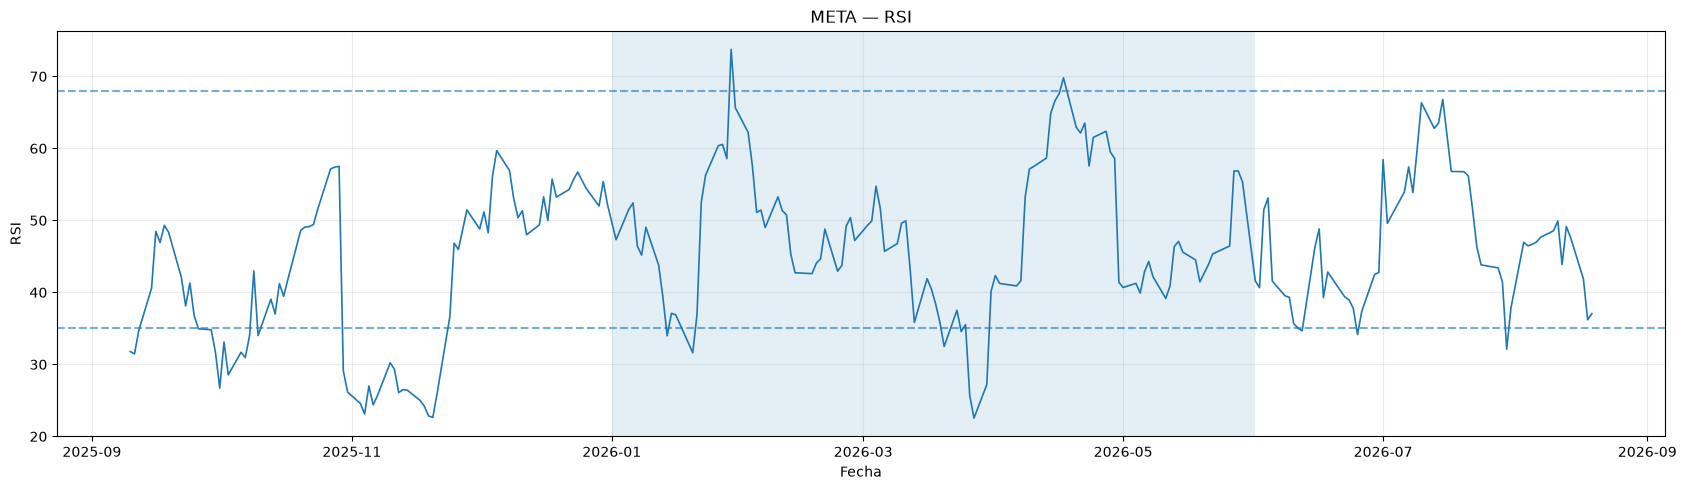

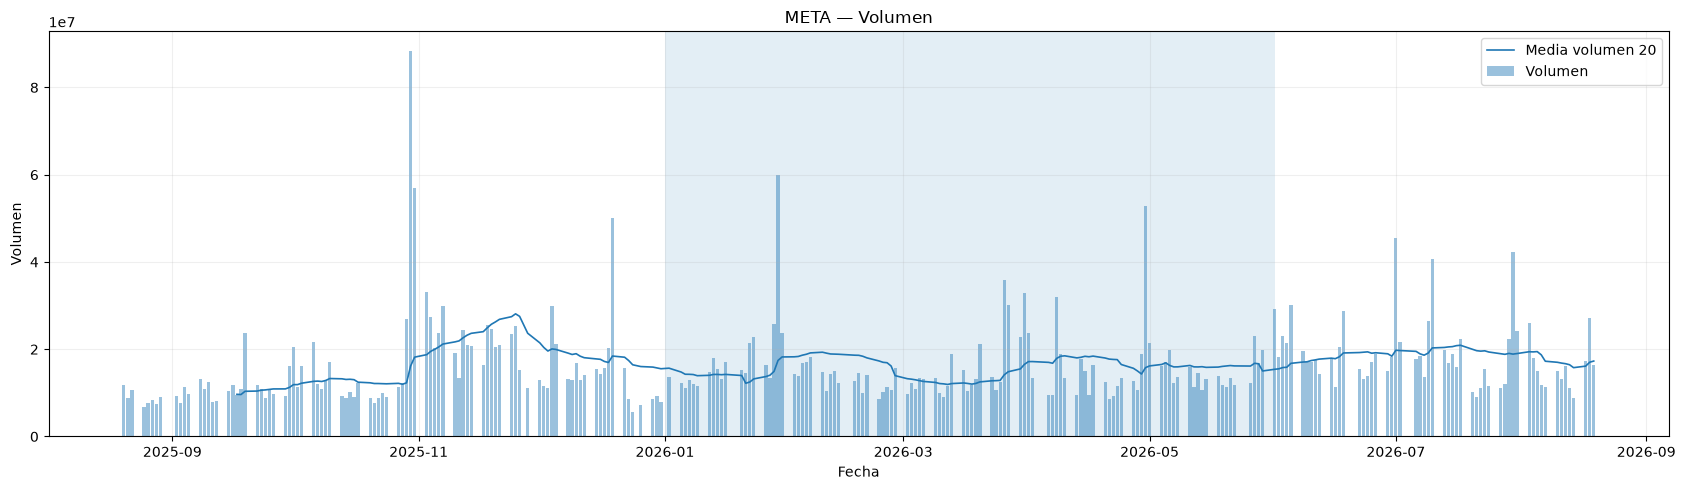

In [12]:

# ================================================================
# 📊 RSI Y VOLUMEN — DIAGNÓSTICO
# ================================================================

plt.figure(figsize=(17, 5))

plt.plot(sig["Date"], sig["RSI"], linewidth=1.2)
plt.axhline(RSI_SUELO, linestyle="--", alpha=0.6)
plt.axhline(RSI_TECHO, linestyle="--", alpha=0.6)

plt.axvspan(
    pd.Timestamp(FECHA_OPERATIVA_INICIO),
    pd.Timestamp(FECHA_OPERATIVA_FIN),
    alpha=0.12
)

plt.title(f"{TICKER} — RSI")
plt.xlabel("Fecha")
plt.ylabel("RSI")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


plt.figure(figsize=(17, 5))

plt.bar(
    sig["Date"],
    sig["Volume"],
    alpha=0.45,
    label="Volumen"
)

plt.plot(
    sig["Date"],
    sig["Vol_Media"],
    linewidth=1.2,
    label=f"Media volumen {VOLUMEN_PERIODO}"
)

plt.axvspan(
    pd.Timestamp(FECHA_OPERATIVA_INICIO),
    pd.Timestamp(FECHA_OPERATIVA_FIN),
    alpha=0.12
)

plt.title(f"{TICKER} — Volumen")
plt.xlabel("Fecha")
plt.ylabel("Volumen")
plt.grid(True, alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()
